In [20]:
# Presentation:
# - Multi-Object

In [21]:
# reloads modules before executing
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
from classes.particle_filter import ParticleFilter
from classes.particle_filter_multiple import MultiObjectParticleFilter
from classes.observation import TransitionModel, ObservationModel
from classes.simulator import create_ground_truth, generate_random_balls, create_ground_truth_n_balls
from classes.plotting import plot_sim_n_balls_point_prediction, plot_particles_at_time, animate_particle_filter
from classes.evaluator import print_stats
import numpy as np

In [23]:
np.random.seed()

n_objects = 4
step_size = 0.05
num_steps = 120
dropout_start = 20
dropout_end = 30
process_noise = 1

measurement_noise = 5
roughening_noise = 1


num_particles = 1000
init_generator = "Sobol"

state_bounds = [
    (0.0, 50.0),   # x bounds
    (0.0, 50.0),   # y bounds
    (-30.0, 30.0),   # vx bounds
    (0.0, 40.0)    # vy bounds
]

# Crossing Each Other
true_states_multi = np.array([
    [20.0, 20.0, 2.0, 25.0],
    [20.0, 20.0, 2.0, 30.0],
    [30.0, 20.0, -2.0, 25.0],
    [30.0, 20.0, -2.0, 30.0]
], dtype=float)

# Similar Trajectories
# true_states_multi = np.array([
#     [5.0, 5.0, 18.0, 25.0],
#     [5.0, 5.0, 18.0, 30.0],
#     [5.0, 5.0, 18.0, 35.0],
#     [5.0, 5.0, 18.0, 40.0]
# ], dtype=float)

# Create multi-ball physics models


transition_model = TransitionModel(delta_t=step_size, process_noise=1)

observation_model = ObservationModel("Gaussian", measurement_noise=measurement_noise)
model_transition_model = TransitionModel(delta_t=step_size, process_noise=process_noise)

# Generate multi-ball paths and sensor reads
true_trajectory_multi, observations_multi = create_ground_truth_n_balls(
    num_steps, dropout_start, dropout_end, true_states_multi, transition_model, observation_model
)

# Initialize Particle Filter with expanded particle cloud for multi-modality
pf_multi = MultiObjectParticleFilter(
    num_particles=num_particles,
    n_balls=n_objects,
    state_bounds=state_bounds,
    transition_model=model_transition_model,
    observation_model=observation_model,
    init_generator=init_generator,
    roughening_noise=roughening_noise,
)

# pf_single = ParticleFilter(
#     num_particles=num_particles * n_objects,  # more particles to equalize playing field
#     state_bounds=state_bounds,
#     transition_model=model_transition_model,
#     observation_model=observation_model,
#     init_generator=init_generator,
#     roughening_noise=roughening_noise
# )

# Run the tracking engine
history_multi = pf_multi.run(observations_multi)

# history_single = pf_single.run(observations_multi, n_objects=n_objects)


c:\THWS\THWS\1. Semester\RDM\New_Particle_Filter\classes\particle_filter_multiple.py:109: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


t=0  assignment={np.int64(0): np.int64(3), np.int64(1): np.int64(2), np.int64(2): np.int64(0), np.int64(3): np.int64(1)}
  ball 0: x=29.2  y=17.1  vx=1.55  vy=18.87
  ball 1: x=31.9  y=24.3  vx=0.55  vy=21.87
  ball 2: x=17.5  y=21.2  vx=-2.19  vy=17.52
  ball 3: x=20.4  y=20.9  vx=1.05  vy=16.70
t=1  assignment={np.int64(0): np.int64(3), np.int64(1): np.int64(2), np.int64(2): np.int64(1), np.int64(3): np.int64(0)}
  ball 0: x=26.8  y=21.7  vx=-5.84  vy=23.22
  ball 1: x=29.1  y=24.2  vx=-3.94  vy=20.70
  ball 2: x=18.3  y=18.3  vx=2.94  vy=13.27
  ball 3: x=19.5  y=19.8  vx=-4.48  vy=13.09
t=2  assignment={np.int64(0): np.int64(2), np.int64(1): np.int64(3), np.int64(2): np.int64(1), np.int64(3): np.int64(0)}
  ball 0: x=27.4  y=23.8  vx=-4.81  vy=23.95
  ball 1: x=32.1  y=24.2  vx=9.42  vy=17.93
  ball 2: x=19.8  y=19.9  vx=7.07  vy=14.51
  ball 3: x=19.3  y=21.0  vx=-5.77  vy=13.12
t=3  assignment={np.int64(0): np.int64(2), np.int64(1): np.int64(3), np.int64(2): np.int64(0), np.int64

In [24]:
# plot_sim_n_balls_point_prediction(
#     true_trajectory_multi,
#     observations_multi,
#     history_single,
#     dropout_start,
#     dropout_end
# )

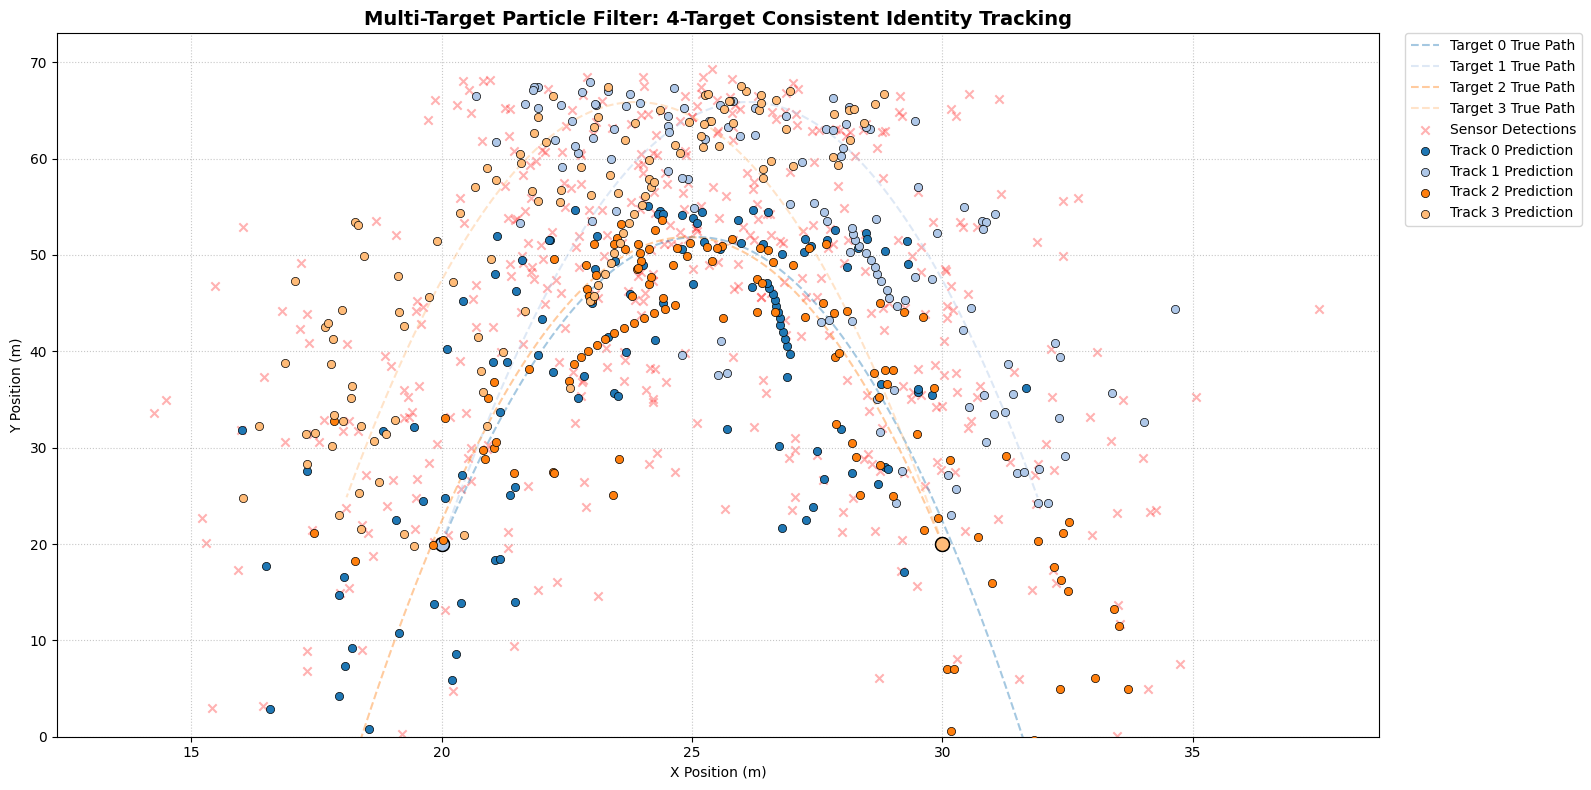

In [25]:
plot_sim_n_balls_point_prediction(
    true_trajectory_multi,
    observations_multi,
    history_multi,
    dropout_start,
    dropout_end
)

In [26]:
animate_particle_filter(true_trajectory_multi, history_multi, save_path="particle_filter_multiple_animation.gif")
# animate_particle_filter(true_trajectory_multi, history_single, save_path="particle_filter_single_animation.gif")


Animation saved to particle_filter_multiple_animation.gif


In [27]:
from PIL import Image
import io
import ipywidgets as widgets
from IPython.display import display

# load frames from GIF
gif_path = "particle_filter_multiple_animation.gif"
pil = Image.open(gif_path)
frames_bytes = []
try:
    i = 0
    while True:
        pil.seek(i)
        buf = io.BytesIO()
        pil.convert("RGBA").save(buf, format="PNG")
        frames_bytes.append(buf.getvalue())
        i += 1
except EOFError:
    pass

# widgets
img = widgets.Image(value=frames_bytes[0], format='png', width=640*2, height=480*2)
slider = widgets.IntSlider(min=0, max=len(frames_bytes)-1, description='Frame')
play = widgets.Play(min=0, max=len(frames_bytes)-1, interval=200)

widgets.jslink((play, 'value'), (slider, 'value'))

def on_frame_change(change):
    img.value = frames_bytes[change['new']]

slider.observe(on_frame_change, names='value')

controls = widgets.HBox([play, slider])
display(controls, img)

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x06@\x00\x00\x03 \x08\x06\x00\x00\x00{\xc0\xaeZ\x00\…

In [28]:
# from PIL import Image
# import io
# import ipywidgets as widgets
# from IPython.display import display

# # load frames from GIF
# gif_path = "particle_filter_single_animation.gif"
# pil = Image.open(gif_path)
# frames_bytes = []
# try:
#     i = 0
#     while True:
#         pil.seek(i)
#         buf = io.BytesIO()
#         pil.convert("RGBA").save(buf, format="PNG")
#         frames_bytes.append(buf.getvalue())
#         i += 1
# except EOFError:
#     pass

# # widgets
# img = widgets.Image(value=frames_bytes[0], format='png', width=640*2, height=480*2)
# slider = widgets.IntSlider(min=0, max=len(frames_bytes)-1, description='Frame')
# play = widgets.Play(min=0, max=len(frames_bytes)-1, interval=200)

# widgets.jslink((play, 'value'), (slider, 'value'))

# def on_frame_change(change):
#     img.value = frames_bytes[change['new']]

# slider.observe(on_frame_change, names='value')

# controls = widgets.HBox([play, slider])
# display(controls, img)

In [29]:
print_stats(true_trajectory_multi, observations_multi, history_multi, num_steps)
# print_stats(true_trajectory_multi, observations_multi, history_single, num_steps)

Estimate Mean error: 1.8845157977990017
Estimate RMSE: 2.129855320835304
Observation Mean error: 2.7645472482954996
Observation RMSE: 3.1043451295382627
